In [1]:
print("Hello Analyst 🚀")

Hello Analyst 🚀


In [2]:
import pandas as pd


In [3]:
import pandas as pd

In [4]:
df = pd.read_csv(r"C:\Users\HP\Downloads\project\online_retail.csv")

In [5]:
df.head()


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [6]:
df.shape

(541909, 8)

In [7]:
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='object')

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [9]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [10]:
df = df.dropna()

In [11]:
df.isnull().sum()

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64

In [12]:
df.shape

(406829, 8)

In [13]:
df.duplicated().sum()

np.int64(5225)

In [14]:
df = df.drop_duplicates()

In [15]:
df = df[df['Quantity'] > 0]

In [16]:
df = df[df['UnitPrice'] > 0]

In [17]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

In [18]:
df.info()


<class 'pandas.core.frame.DataFrame'>
Index: 392692 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    392692 non-null  object        
 1   StockCode    392692 non-null  object        
 2   Description  392692 non-null  object        
 3   Quantity     392692 non-null  int64         
 4   InvoiceDate  392692 non-null  datetime64[ns]
 5   UnitPrice    392692 non-null  float64       
 6   CustomerID   392692 non-null  float64       
 7   Country      392692 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 27.0+ MB


In [19]:
df['Revenue'] = df['Quantity'] * df['UnitPrice']

In [20]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [21]:
df['Revenue'].sum()

np.float64(8887208.894000001)

In [22]:
top_products = df.groupby('Description')['Revenue'].sum()

top_products.sort_values(ascending=False).head(10)

Description
PAPER CRAFT , LITTLE BIRDIE           168469.60
REGENCY CAKESTAND 3 TIER              142264.75
WHITE HANGING HEART T-LIGHT HOLDER    100392.10
JUMBO BAG RED RETROSPOT                85040.54
MEDIUM CERAMIC TOP STORAGE JAR         81416.73
POSTAGE                                77803.96
PARTY BUNTING                          68785.23
ASSORTED COLOUR BIRD ORNAMENT          56413.03
Manual                                 53419.93
RABBIT NIGHT LIGHT                     51251.24
Name: Revenue, dtype: float64

In [23]:
top_countries = df.groupby('Country')['Revenue'].sum()

top_countries.sort_values(ascending=False).head(10)

Country
United Kingdom    7285024.644
Netherlands        285446.340
EIRE               265262.460
Germany            228678.400
France             208934.310
Australia          138453.810
Spain               61558.560
Switzerland         56443.950
Belgium             41196.340
Sweden              38367.830
Name: Revenue, dtype: float64

In [24]:
df['Month'] = df['InvoiceDate'].dt.to_period('M')

In [25]:
monthly_sales = df.groupby('Month')['Revenue'].sum()

monthly_sales

Month
2010-12     570422.730
2011-01     568101.310
2011-02     446084.920
2011-03     594081.760
2011-04     468374.331
2011-05     677355.150
2011-06     660046.050
2011-07     598962.901
2011-08     644051.040
2011-09     950690.202
2011-10    1035642.450
2011-11    1156205.610
2011-12     517190.440
Freq: M, Name: Revenue, dtype: float64

In [26]:
monthly_sales.sort_values(ascending=False).head()

Month
2011-11    1156205.610
2011-10    1035642.450
2011-09     950690.202
2011-05     677355.150
2011-06     660046.050
Freq: M, Name: Revenue, dtype: float64

In [27]:
df['Revenue'].mean()

np.float64(22.631499735161402)

In [28]:
df['CustomerID'].nunique()

4338

In [29]:
best_quantity = df.groupby('Description')['Quantity'].sum()

best_quantity.sort_values(ascending=False).head(10)

Description
PAPER CRAFT , LITTLE BIRDIE           80995
MEDIUM CERAMIC TOP STORAGE JAR        77916
WORLD WAR 2 GLIDERS ASSTD DESIGNS     54319
JUMBO BAG RED RETROSPOT               46078
WHITE HANGING HEART T-LIGHT HOLDER    36706
ASSORTED COLOUR BIRD ORNAMENT         35263
PACK OF 72 RETROSPOT CAKE CASES       33670
POPCORN HOLDER                        30919
RABBIT NIGHT LIGHT                    27153
MINI PAINT SET VINTAGE                26076
Name: Quantity, dtype: int64

In [30]:
import matplotlib.pyplot as plt

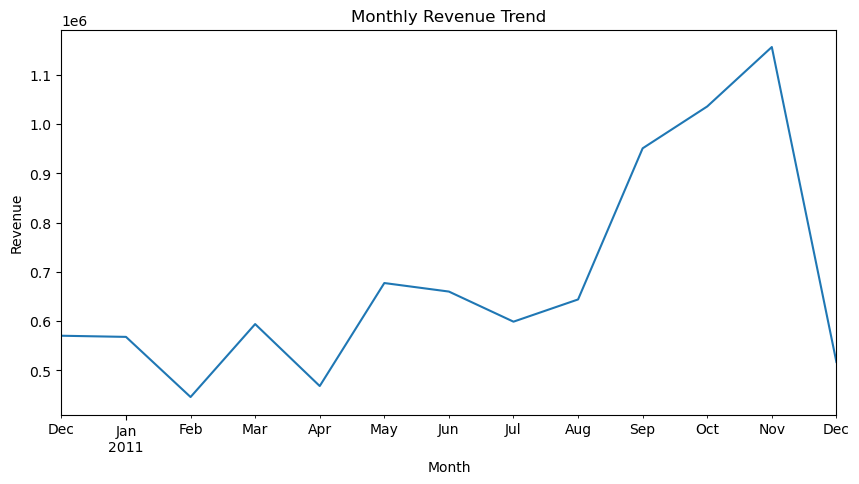

In [31]:
monthly_sales.plot(figsize=(10,5))

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")

plt.show()


In [32]:
df['Month'] = df['InvoiceDate'].dt.to_period('M')

In [33]:
import pandas as pd


In [34]:
df = pd.read_csv(r"C:\Users\HP\Downloads\project\online_retail.csv")

In [35]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

In [36]:
df['Revenue'] = df['Quantity'] * df['UnitPrice']

In [37]:
df['Month'] = df['InvoiceDate'].dt.to_period('M')

In [38]:
monthly_sales = df.groupby('Month')['Revenue'].sum()

In [39]:
import matplotlib.pyplot as plt

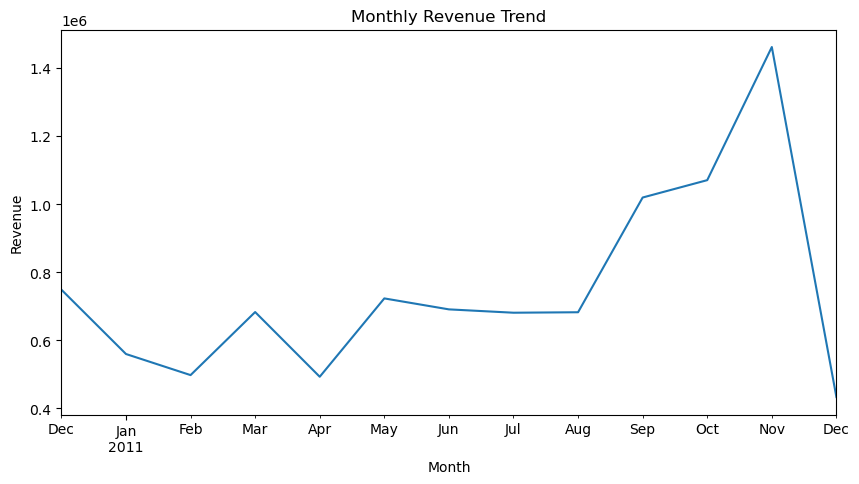

In [40]:
monthly_sales.plot(figsize=(10,5))

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")

plt.show()

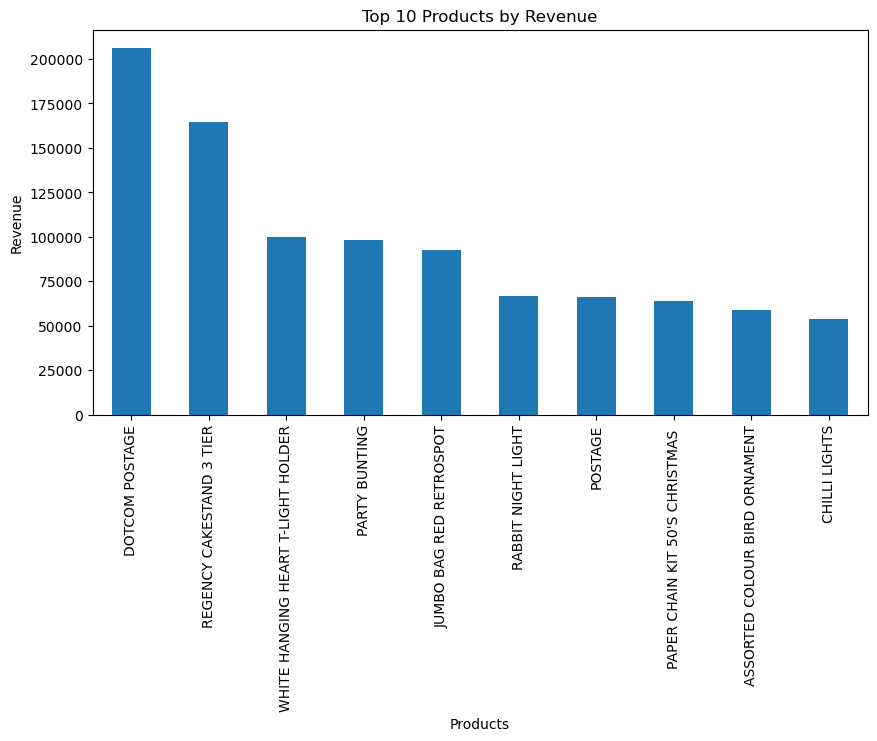

In [41]:

top_products = df.groupby('Description')['Revenue'].sum()

top_products = top_products.sort_values(ascending=False).head(10)

top_products.plot(kind='bar', figsize=(10,5))

plt.title("Top 10 Products by Revenue")
plt.xlabel("Products")
plt.ylabel("Revenue")

plt.show()

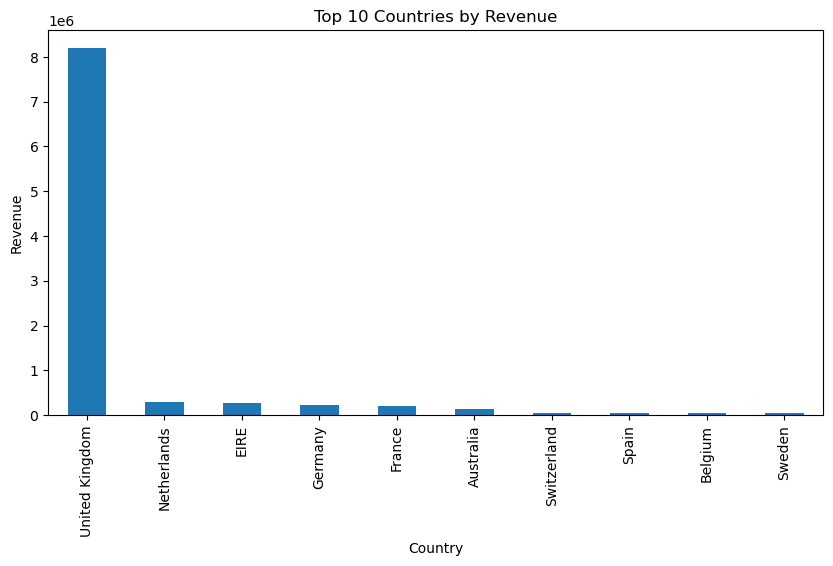

In [42]:
top_countries = df.groupby('Country')['Revenue'].sum()

top_countries = top_countries.sort_values(ascending=False).head(10)

top_countries.plot(kind='bar', figsize=(10,5))

plt.title("Top 10 Countries by Revenue")
plt.xlabel("Country")
plt.ylabel("Revenue")

plt.show()

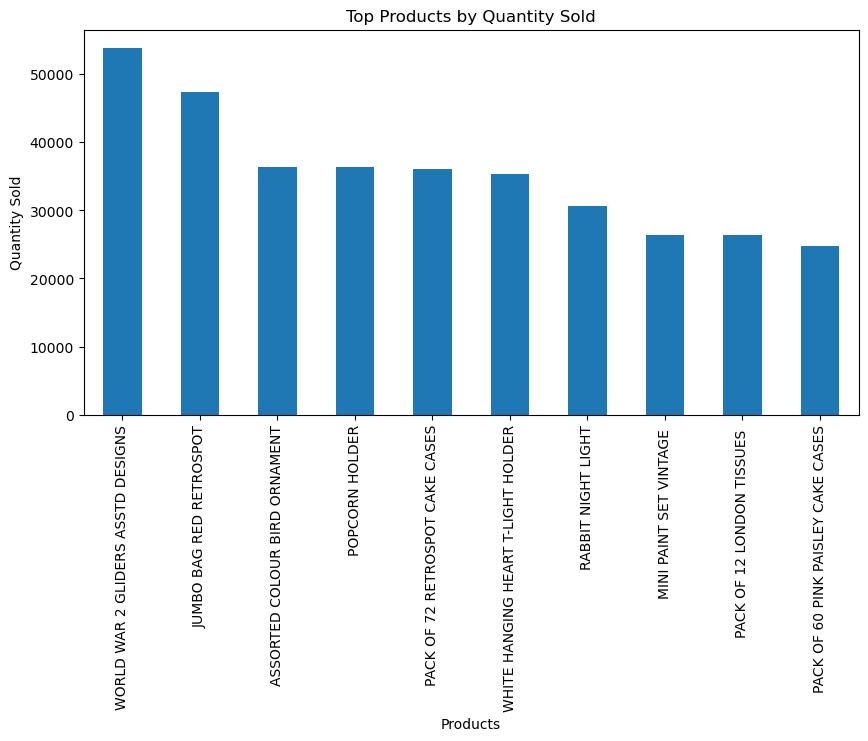

In [43]:
best_quantity = df.groupby('Description')['Quantity'].sum()

best_quantity = best_quantity.sort_values(ascending=False).head(10)

best_quantity.plot(kind='bar', figsize=(10,5))

plt.title("Top Products by Quantity Sold")
plt.xlabel("Products")
plt.ylabel("Quantity Sold")

plt.show()

## Business Insights

- The United Kingdom generated the highest revenue.
- Sales increased during holiday months.
- A few products contributed major revenue.

## Recommendations

- Focus marketing efforts on high-performing countries.
- Increase stock availability for top-selling products.
- Use seasonal sales trends for planning future campaigns.
- Promote high-demand products through bundle offers.
- Analyze low-performing regions for growth opportunities.

## Conclusion


This project analyzed online retail sales data to identify revenue trends, top-performing products, and regional sales performance. The findings can help businesses improve marketing strategies, optimize inventory management, and make data-driven decisions for future growth.